In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray, DTypeLike
import torch as T
from torch import nn
from torch.optim import Adam
from torch.distributions import Normal, TransformedDistribution, TanhTransform, Distribution, AffineTransform, ComposeTransform
from tqdm import tqdm
from typing import Iterator, Protocol, Literal, Any


In [2]:
NUM_ENVS = 8
BATCH_SIZE = 1024
MINIBATCH_SIZE = 128
EPOCHS = 4
STACK_SIZE = 4
DEVICE = T.device("cuda" if T.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [3]:
env = gym.make_vec(
    "CarRacing-v3",
    num_envs=NUM_ENVS,
    vectorization_mode=gym.VectorizeMode.ASYNC,
    # render_mode="rgb_array",
    continuous=True,
    wrappers=[
        lambda env: gym.wrappers.GrayscaleObservation(env, keep_dim=True),
        lambda env: gym.wrappers.FrameStackObservation(env, stack_size=STACK_SIZE),
        lambda env: gym.wrappers.RecordEpisodeStatistics(env),
    ]
)
obs, _ = env.reset()
print(obs.shape, obs.dtype)

(8, 4, 96, 96, 1) uint8


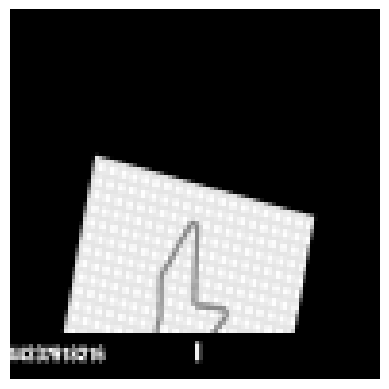

In [4]:
plt.imshow(obs[0, 0], cmap="grey")
plt.axis("off")
plt.show()

In [5]:
print(env.observation_space)
print(env.action_space)

Box(0, 255, (8, 4, 96, 96, 1), uint8)
Box([[-1.  0.  0.]
 [-1.  0.  0.]
 [-1.  0.  0.]
 [-1.  0.  0.]
 [-1.  0.  0.]
 [-1.  0.  0.]
 [-1.  0.  0.]
 [-1.  0.  0.]], 1.0, (8, 3), float32)


In [6]:
sample_action = env.action_space.sample()
print("sample action", sample_action, ", action shape:", sample_action.shape, ", type:", sample_action.dtype)
observation, reward, terminated, truncated, info = env.step(sample_action)
print("observation shape:", observation.shape)
print("reward:", reward, ", terminated:", terminated, ", truncated:", truncated, ", info:", info)

sample action [[ 0.42447683  0.5732957   0.12824605]
 [ 0.7239671   0.6380452   0.115449  ]
 [ 0.77578396  0.57483065  0.24781981]
 [-0.40509441  0.8022092   0.8067167 ]
 [ 0.37018913  0.02444035  0.9106016 ]
 [ 0.11406547  0.32161224  0.90491045]
 [ 0.6141432   0.6087896   0.60090667]
 [-0.39774296  0.57877433  0.0811159 ]] , action shape: (8, 3) , type: float32
observation shape: (8, 4, 96, 96, 1)
reward: [7.33494424 7.56283525 7.93212851 6.31025641 6.67966102 6.74931507
 7.41879699 6.54451827] , terminated: [False False False False False False False False] , truncated: [False False False False False False False False] , info: {}


In [7]:
@dataclass(slots=True, frozen=True)
class RolloutStep:
    observation: NDArray[np.uint8]
    action: NDArray[np.float32]
    critic_value: NDArray[np.float32]
    old_log_probs: NDArray[np.float32]
    reward: NDArray[np.float32]
    terminated: NDArray[np.bool_]
    truncated: NDArray[np.bool_]


def to_tensor_batch(minibatch: dict[str, NDArray], device: T.device) -> dict[str, T.Tensor]:
    return {k: T.from_numpy(v).to(device) for k, v in minibatch.items()}


# Rollout Buffer
class RolloutBuffer:
    def __init__(self, size: int, num_envs: int, observation_space: tuple[int, ...], action_space: tuple[int, ...], obs_dtype: np.dtype = np.dtype(np.uint8)):
        self.size = size
        self._num_envs = num_envs
        self._observation_space = observation_space
        self._action_space = action_space
        self._obs_dtype = obs_dtype
        self._buffer: dict[str, NDArray] = {}
        self._counter: int = 0
        self._cached_flat: dict[str, NDArray] | None = None
        self._cache_key: tuple[int, float, float] | None = None
        self.reset()

    def is_full(self) -> bool:
        return self._counter == self.size

    def add(self, step: RolloutStep):
        i = self._counter
        self._buffer["observation"][:, i] = step.observation
        self._buffer["action"][:, i] = step.action
        self._buffer["critic_value"][:, i] = step.critic_value
        self._buffer["old_log_probs"][:, i] = step.old_log_probs
        self._buffer["reward"][:, i] = step.reward
        self._buffer["terminated"][:, i] = step.terminated
        self._buffer["truncated"][:, i] = step.truncated
        self._counter += 1
        self._cached_flat = None

    @staticmethod
    def compute_returns_and_advantages(
        reward: NDArray[np.float32],
        critic_value: NDArray[np.float32],
        done: NDArray[np.bool_],
        gamma: float = 0.99,
        gae_lambda: float = 0.95,
    ) -> tuple[NDArray[np.float32], NDArray[np.float32]]:
        delta = reward[:, :-1] + gamma * critic_value[:, 1:] * np.logical_not(done[:, :-1]) - critic_value[:, :-1]
        advantages = np.zeros_like(delta)
        last_gae_lam = 0
        for i in reversed(range(advantages.shape[1])):
            last_gae_lam = delta[:, i] + gamma * gae_lambda * last_gae_lam * np.logical_not(done[:, i])
            advantages[:, i] = last_gae_lam
        returns = advantages + critic_value[:, :-1]
        return returns, advantages

    def _build_observation_windows(self, obs: NDArray[np.uint8], done: NDArray[np.bool_], stack_size: int) -> NDArray[np.uint8]:
        """
        Returns shape (size, num_envs, stack_size, *observation_space).
        stacked[n, t] = last `stack_size` frames ending at t, for env n,
        clipped at episode boundaries (terminated/truncated) and buffer start,
        padded by repeating the earliest available frame.
        """
        T_, N, k = self.size, self._num_envs, stack_size
        # obs = self._buffer["observation"]
        # done = self._buffer["terminated"] | self._buffer["truncated"]

        stacked = np.zeros((N, T_, k) + self._observation_space, dtype=self._obs_dtype)
        for n in range(N):
            window_start = 0
            for t in range(T_):
                if t > 0 and done[n, t - 1]:
                    window_start = t
                lo = max(window_start, t - k + 1)
                frames = obs[n, lo:t + 1]
                pad = k - frames.shape[0]
                if pad > 0:
                    frames = np.concatenate([np.repeat(frames[:1], pad, axis=0), frames], axis=0)
                stacked[n, t] = frames
        return stacked

    def get_flat_trajectory(self, stack_size: int, gamma: float = 0.99, gae_lambda: float = 0.95) -> dict[str, NDArray]:
        cache_key = (stack_size, gamma, gae_lambda)
        if self._cached_flat is not None and self._cache_key == cache_key:
            return self._cached_flat

        done = np.logical_or(self._buffer["terminated"], self._buffer["truncated"])
        returns, advantages = self.compute_returns_and_advantages(
            self._buffer["reward"], self._buffer["critic_value"], done, gamma, gae_lambda,
        )
        obs_windows = self._build_observation_windows(self._buffer["observation"], done, stack_size=stack_size)
        flat = {
            "observation": obs_windows[:, :-1].reshape(-1, stack_size, *self._observation_space),
            "action": self._buffer["action"][:, :-1].reshape(-1, *self._action_space),
            "old_log_probs": self._buffer["old_log_probs"][:, :-1].reshape(-1),
            "returns": returns.reshape(-1),
            "advantages": advantages.reshape(-1),
        }
        self._cached_flat = flat
        self._cache_key = cache_key
        return flat

    def get_iid_minibatches(self, minibatch_size: int, stack_size: int, rng: np.random.Generator) -> Iterator[dict[str, NDArray]]:
        flat = self.get_flat_trajectory(stack_size)
        n = flat["returns"].shape[0]
        indices = rng.permutation(n)
        for start in range(0, n, minibatch_size):
            idx = indices[start:start + minibatch_size]
            yield {k: v[idx] for k, v in flat.items()}

    @staticmethod
    def _explained_variance(returns: NDArray[np.float32], values: NDArray[np.float32]) -> float:
        var_returns = np.var(returns)
        if var_returns < 1e-8:
            return float("nan")  # degenerate — targets have no variance to explain
        return float(1 - np.var(returns - values) / var_returns)

    def get_metrics(self, stack_size: int, gamma: float = 0.99, gae_lambda: float = 0.95) -> dict[str, float]:
        flat = self.get_flat_trajectory(stack_size, gamma, gae_lambda)  # reuses cache
        returns = flat["returns"]
        values = self._buffer["critic_value"][:, :-1].reshape(-1)
        actions = flat["action"]
        action_mean = actions.mean(0)
        action_std = actions.std(0)

        metrics = {
            "rollout/value_target_mean": float(returns.mean()),
            "rollout/value_target_std": float(returns.std()),
            "rollout/value_pred_mean": float(values.mean()),
            "rollout/explained_variance": self._explained_variance(returns, values),
        }
        
        metrics.update({
            f"rollout/action_mean_{i}": float(v) for i, v in enumerate(action_mean)
        })

        metrics.update({
            f"rollout/action_std_{i}": float(v) for i, v in enumerate(action_std)
        })

        return metrics

    def reset(self):
        self._buffer = {
            "observation": np.zeros((self._num_envs, self.size) + self._observation_space, self._obs_dtype),
            "action": np.zeros((self._num_envs, self.size) + self._action_space, np.float32),
            "critic_value": np.zeros((self._num_envs, self.size), np.float32),
            "old_log_probs": np.zeros((self._num_envs, self.size), np.float32),
            "reward": np.zeros((self._num_envs, self.size), np.float32),
            "truncated": np.zeros((self._num_envs, self.size), np.bool_),
            "terminated": np.zeros((self._num_envs, self.size), np.bool_),
        }
        self._counter: int = 0
        self._cached_flat = None
        self._cache_key = None


In [8]:
buffer = RolloutBuffer(BATCH_SIZE, NUM_ENVS, env.observation_space.shape[-3:], env.action_space.shape[-1:])

In [ ]:
def init_layer(layer: nn.Module, gain: float = np.sqrt(2), bias: float = 0.0) -> nn.Module:
    nn.init.orthogonal_(layer.weight, gain)
    nn.init.constant_(layer.bias, bias)
    return layer


class CNN(nn.Module):
    def __init__(self, observation_dim: int):
        super().__init__()
        self._network = nn.Sequential(
            init_layer(nn.Conv2d(observation_dim, 32, kernel_size=8, stride=4)),
            nn.ReLU(),
            init_layer(nn.Conv2d(32, 64, kernel_size=4, stride=2)),
            nn.ReLU(),
            init_layer(nn.Conv2d(64, 64, kernel_size=3, stride=1)),
            nn.ReLU(),
            nn.Flatten(),
            init_layer(nn.Linear(4096, 512)),
            nn.ReLU(),
            init_layer(nn.Linear(512, 512)),
        )

    def forward(self, x: T.Tensor) -> T.Tensor:
        return self._network(x)

class Actor(nn.Module):
    def __init__(self, action_dim: int):
        super().__init__()
        self._network = nn.Sequential(
            init_layer(nn.Linear(512, 256)),
            nn.ReLU(),
            init_layer(nn.Linear(256, action_dim), gain=0.01),  # near-uniform initial policy
        )
        self._log_std = nn.Parameter(T.full((action_dim,), -0.5))

        # register as buffers instead of plain tensors
        self.register_buffer("_affine_loc", T.tensor([0., 0.5, 0.5]))
        self.register_buffer("_affine_scale", T.tensor([1., 0.5, 0.5]))

    def forward(self, x: T.Tensor, temperature: float = 1.) -> Distribution:
        mean = self._network(x)
        std = self._log_std.clamp(-2.0, 0.5).exp() * temperature

        assert T.isfinite(mean).all(), mean
        assert T.isfinite(std).all(), std

        return TransformedDistribution(
            Normal(mean, std),
            transforms=ComposeTransform(
                [
                    TanhTransform(),
                    AffineTransform(loc=self._affine_loc, scale=self._affine_scale),
                ]
            )
        )

class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self._network = nn.Sequential(
            init_layer(nn.Linear(512, 256)),
            nn.ReLU(),
            init_layer(nn.Linear(256, 1), gain=1.0),  # standard, not sqrt(2), for value head
        )

    def forward(self, x: T.Tensor) -> T.Tensor:
        return self._network(x).squeeze_(-1)


class PPONetwork(nn.Module):
    def __init__(self, observation_dim: int, action_dim: int, stack_size: int):
        super().__init__()

        self.cnn = CNN(observation_dim)
        self.sequence_encoder = nn.Conv1d(
            512, 512, kernel_size=stack_size
        )
        # self.norm = nn.LayerNorm(512)
        self.actor = Actor(action_dim)
        self.critic = Critic()

    def forward(self, observation: T.Tensor, temperature: float = 1.) -> tuple[Distribution, T.Tensor]:
        x = observation.view(-1, *observation.shape[-3:])
        x = self.cnn(x)

        x = x.view(observation.shape[0], -1, x.shape[-1])
        x = self.sequence_encoder(x.permute(0, 2, 1)).squeeze_(-1)
        x = self.norm(x)

        action_dist = self.actor(x, temperature=temperature)
        value = self.critic(x)

        return action_dist, value


def clamp_action(
    action: T.Tensor,
    low: T.Tensor,
    high: T.Tensor,
    eps: float = 1e-6,
) -> T.Tensor:
    margin = eps * (high - low)
    return T.clamp(action, low + margin, high - margin)


class Agent:
    def __init__(self, observation_dim: int, action_dim: int, stack_size: int):
        self._observation_dim = observation_dim
        self._action_dim = action_dim
        self._stack_size = stack_size
        self._device = T.device("cuda" if T.cuda.is_available() else "cpu")
        self._network = PPONetwork(
            observation_dim,
            action_dim,
            stack_size
        ).to(self._device)
        self._clamp_min = T.Tensor([-1., 0., 0.]).to(self._device)
        # self._clamp_max = T.Tensor([1., 1., 1.]).to(self._device)

    def _preprocess_observation(self, observation: NDArray[np.uint8] | T.Tensor) -> T.Tensor:
        if isinstance(observation, np.ndarray):
            # freshly created tensor — safe to mutate in place
            observation_tensor = T.from_numpy(observation).to(self._device, T.float32)
            
        else:
            # caller-owned tensor — don't mutate their storage
            observation_tensor = observation.to(self._device, T.float32)
        observation_tensor.div_(255. / 2.).sub_(1.)

        return observation_tensor.permute(0, 1, 4, 2, 3)

    def evaluate_actions(self, observation: NDArray[np.uint8] | T.Tensor, action: NDArray[np.float32] | T.Tensor) -> tuple[T.Tensor, T.Tensor, Distribution]:
        obs = self._preprocess_observation(observation)
        result: tuple[Distribution, T.Tensor] = self._network(obs)
        action_dist, value = result

        action_tensor = T.from_numpy(action) if isinstance(action, np.ndarray) else action
        action_tensor = action_tensor.to(self._device)
        log_probs = action_dist.log_prob(action_tensor).sum(dim=-1)
        return log_probs, value, action_dist

    def act(self, observation: NDArray[np.uint8], temperature: float = 1.) -> tuple[NDArray[np.float32], NDArray[np.float32], NDArray[np.float32]]:
        obs = self._preprocess_observation(observation)
        result: tuple[Distribution, T.Tensor] = self._network(obs, temperature=temperature)
        action_dist, value = result
        action = action_dist.sample().detach()
        # action = clamp_action(action, self._clamp_min, self._clamp_max)
        log_probs = action_dist.log_prob(action).sum(dim=-1)
        return action.cpu().numpy(), log_probs.detach().cpu().numpy(), value.detach().cpu().numpy()

In [10]:
agent = Agent(env.observation_space.shape[-1], env.action_space.shape[-1], stack_size=STACK_SIZE)

In [ ]:
class RecordVideoCallback:
    def __init__(self, env_id: str, agent: Agent, video_dir: str, interval: int = 10_000):
        self.agent = agent
        self.video_dir = video_dir
        self.env = self._make_env(env_id, self.agent._stack_size)
        self.interval = interval

    def _make_env(self, env_id: str, stack_size: int):
        return gym.make_vec(
            env_id,
            num_envs=1,
            vectorization_mode=gym.VectorizeMode.SYNC,
            render_mode="rgb_array",
            continuous=True,
            wrappers=[
                lambda env: gym.wrappers.RecordVideo(
                    env, self.video_dir, episode_trigger=lambda ep: True
                ),
                lambda env: gym.wrappers.GrayscaleObservation(env, keep_dim=True),
                lambda env: gym.wrappers.FrameStackObservation(env, stack_size=stack_size),
                lambda env: gym.wrappers.RecordEpisodeStatistics(env),
            ]
        )

    def record(self):
        self.agent._network.eval()
        print("Recording video...")
        state, _ = self.env.reset()
        done = False
        while not done:
            action, _, _ = self.agent.act(state, temperature=1e-4)
            state, _, terminated, truncated, info = self.env.step(action)
            done = np.logical_or(terminated, truncated).any()
        print(info)
        self.agent._network.train()
        return

    def on_start(self, *args, **kwargs):
        pass

    def on_step(self, *args, **kwargs):
        pass

    def on_epoch(self, *args, **kwargs):
        pass

    def on_end(self, *args, **kwargs):
        pass

    def on_rollout_start(self, *args, **kwargs):
        pass

    def on_env_step(self, step: int, *args, **kwargs):
        if step % self.interval == 0:
            self.record()

    def on_rollout_end(self, *args, **kwargs):
        self.record()
        self.env.close()

record_video_callback = RecordVideoCallback(
    env_id="CarRacing-v3",
    agent=agent,
    video_dir="./videos/",
    interval=50_000,
)
        

/workspace/TrackmaniaRL/.venv/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /workspace/TrackmaniaRL/notebooks/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [12]:
class MetricsLogger(ABC):
    @abstractmethod
    def log_metrics(self, metrics: dict[str, float], step: int) -> None: ...


class ConsoleMetricsLogger(MetricsLogger):
    def log_metrics(self, metrics: dict[str, float], step: int) -> None:
        formatted = {k: f"{v:.4f}" for k, v in metrics.items()}
        print(f"Step {step}: {formatted}")


class MetricsLoggingCallback:
    def __init__(self, logger: MetricsLogger, granularity: Literal["minibatch", "epoch", "batch"] = "epoch"):
        self._logger = logger
        self.granularity = granularity
        self._epoch_buffer: list[dict[str, float]] = []
        self._step = 0

    def on_start(self, step: int, metrics: dict[str, Any], *args, **kwargs):
        self._logger.log_metrics(metrics, step=self._step)
        self._epoch_buffer.clear()

    def on_minibatch(self, metrics: dict[str, float], **kwargs):
        if self.granularity == "minibatch":
            self._step += 1
            self._logger.log_metrics(metrics, step=self._step)
        else:
            self._epoch_buffer.append(metrics)

    def on_epoch(self, *args, **kwargs):
        if self.granularity == "epoch" and self._epoch_buffer:
            keys = self._epoch_buffer[0].keys()
            aggregated = {k: float(np.mean([m[k] for m in self._epoch_buffer])) for k in keys}
            self._step += 1
            self._logger.log_metrics(aggregated, step=self._step)
            self._epoch_buffer.clear()

    def on_end(self, *args, **kwargs):
        if self.granularity == "batch" and self._epoch_buffer:
            keys = self._epoch_buffer[0].keys()
            aggregated = {k: float(np.mean([m[k] for m in self._epoch_buffer])) for k in keys}
            self._step += 1
            self._logger.log_metrics(aggregated, step=self._step)
            self._epoch_buffer.clear()


class TrainingCallback(Protocol):
    def on_start(self, *args, **kwargs) -> None: ...
    def on_minibatch(self, *args, **kwargs) -> None: ...
    def on_end(self, *args, **kwargs) -> None: ...
    def on_epoch(self, *args, **kwargs) -> None: ...

class PPOTrainer:
    def __init__(
        self,
        agent: Agent,
        ppo_epsilon: float = 0.2,
        critic_beta: float = 0.5,
        entropy_coef: float = 0.001,
        callbacks: list[TrainingCallback] | None = None,
    ):
        self._agent = agent
        self._optimizer = Adam(agent._network.parameters(), lr=3e-4, eps=1e-5)
        self.ppo_epsilon = ppo_epsilon
        self.critic_beta = critic_beta
        self.entropy_coef = entropy_coef
        self.critic_loss_fn = nn.MSELoss()
        self._callbacks = callbacks if callbacks is not None else []
        self._step = 0

    def train_step(self, advantages: T.Tensor, returns: T.Tensor, old_log_probs: T.Tensor, observation: T.Tensor, action: T.Tensor) -> dict[str, float]:
        actor_loss, critic_loss, entropy_loss = self.calculate_losses(advantages, returns, old_log_probs, observation, action)
        loss = actor_loss + self.critic_beta * critic_loss - self.entropy_coef * entropy_loss

        self._optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self._agent._network.parameters(), 0.5)
        self._optimizer.step()

        return {
            "loss/total": loss.detach().item(),
            "loss/actor": actor_loss.detach().item(),
            "loss/critic": critic_loss.detach().item(),
            "loss/entropy": entropy_loss.detach().item(),
        }

    def _actor_loss(self, advantages: T.Tensor, log_probs: T.Tensor, old_log_probs: T.Tensor) -> T.Tensor:
        log_ratio = (log_probs - old_log_probs).clamp(-10, 10)  # prevent exp overflow
        ratio = log_ratio.exp_()
        # ratio = (log_probs - old_log_probs).exp_()
        clipped_ratio = ratio.clamp(min=1 - self.ppo_epsilon, max=1 + self.ppo_epsilon)
        surrogate_loss = -T.minimum(ratio * advantages, clipped_ratio * advantages)
        return surrogate_loss.mean()

    def _critic_loss(self, returns: T.Tensor, values: T.Tensor) -> T.Tensor:
        critic_loss = self.critic_loss_fn(returns, values)
        return critic_loss

    # def _entropy_loss(self, log_probs: T.Tensor) -> T.Tensor:
    #     return -log_probs.mean()
    def _entropy_loss(self, dist: Distribution) -> T.Tensor:
        # entropy of the base Normal; TanhTransform doesn't have closed-form entropy
        return dist.base_dist.entropy().sum(dim=-1).mean()


    def calculate_losses(self, advantages: T.Tensor, returns: T.Tensor, old_log_probs: T.Tensor, observation: T.Tensor, action: T.Tensor) -> tuple[T.Tensor, T.Tensor, T.Tensor]:
        log_probs, values, dist = self._agent.evaluate_actions(observation, action)
        normalized_advantages = (advantages - advantages.mean()) / (advantages.std(unbiased=False) + 1e-8)
        actor_loss = self._actor_loss(normalized_advantages, log_probs, old_log_probs)
        critic_loss = self._critic_loss(returns, values)
        entropy_loss = self._entropy_loss(dist)
        return actor_loss, critic_loss, entropy_loss

    def _on_start(self, *args, **kwargs):
        for callback in self._callbacks:
            callback.on_start(*args, **kwargs)

    def _on_minibatch(self, *args, **kwargs):
        for callback in self._callbacks:
            callback.on_minibatch(*args, **kwargs)

    def _on_end(self, *args, **kwargs):
        for callback in self._callbacks:
            callback.on_end(*args, **kwargs)

    def _on_epoch(self, *args, **kwargs):
        for callback in self._callbacks:
            callback.on_epoch(*args, **kwargs)

    def train(self, buffer: RolloutBuffer, epochs: int, minibatch_size: int, rng: np.random.Generator):
        self._on_start(step=self._step, metrics=buffer.get_metrics(STACK_SIZE))
        for epoch in range(epochs):
            for minibatch in buffer.get_iid_minibatches(minibatch_size, STACK_SIZE, rng):
                tensor_batch = to_tensor_batch(minibatch, self._agent._device)
                metrics = self.train_step(**tensor_batch)
                self._on_minibatch(metrics=metrics, step=self._step)
            self._on_epoch()
        self._on_end()
        buffer.reset()


In [13]:
trainer = PPOTrainer(
    agent,
    callbacks=[MetricsLoggingCallback(ConsoleMetricsLogger(), granularity="batch")]
)

In [ ]:
from typing import Any
class CollectorCallback(Protocol):
    def on_rollout_start(self, *args, **kwargs) -> None: ...
    def on_env_step(self, *args, **kwargs) -> None: ...
    def on_rollout_end(self, *args, **kwargs) -> None: ...


class RecordStatisticLoggerCallback:
    def on_rollout_start(self, *args, **kwargs):
        pass

    def on_env_step(self, step: int, info: dict[str, Any], *args, **kwargs):
        if "episode" in info:
            print(info)
            returns = info["episode"]["r"]
            metrics = {"episode returns": returns}
            print(f"Step {step}: Returns = {returns.mean():.2f}")

    def on_rollout_end(self, *args, **kwargs):
        pass


class RolloutCollector:
    def __init__(
        self,
        env: gym.vector.VectorEnv,
        buffer: RolloutBuffer,
        trainer: PPOTrainer,
        epochs: int,
        minibatch_size: int,
        callbacks: list[CollectorCallback] | None = None,
    ):
        self.env = env
        self.buffer = buffer
        self.trainer = trainer
        self.epochs = epochs
        self.minibatch_size = minibatch_size
        self._callbacks = callbacks if callbacks is not None else []

    def _on_rollout_start(self, *args, **kwargs):
        for cb in self._callbacks:
            cb.on_rollout_start(*args, **kwargs)

    def _on_env_step(self, *args, **kwargs):
        for cb in self._callbacks:
            cb.on_env_step(*args, **kwargs)

    def _on_rollout_end(self, *args, **kwargs):
        for cb in self._callbacks:
            cb.on_rollout_end(*args, **kwargs)

    def run(self, training_steps: int, rng: np.random.Generator):
        state, _ = self.env.reset()
        self.buffer.reset()
        self._on_rollout_start()

        for i in tqdm(range(training_steps)):
            with T.no_grad():
                action, log_probs, critic_value = self.trainer._agent.act(state)
            next_state, reward, terminated, truncated, info = self.env.step(action)

            self.buffer.add(RolloutStep(
                observation=state[:, -1, ...],
                action=action,
                critic_value=critic_value,
                old_log_probs=log_probs,
                reward=reward,
                terminated=terminated,
                truncated=truncated,
            ))

            state = next_state
            self._on_env_step(step=i, info=info)

            if self.buffer.is_full():
                self.trainer.train(self.buffer, epochs=self.epochs, minibatch_size=self.minibatch_size, rng=rng)
                self.buffer.reset()

        self._on_rollout_end()

In [15]:

rng = np.random.default_rng(seed=42)

training_steps = 1_000_000
rollout_collector = RolloutCollector(
    env,
    buffer,
    trainer,
    EPOCHS,
    MINIBATCH_SIZE,
    callbacks=[
        RecordStatisticLoggerCallback(),
        record_video_callback
    ]
)

rollout_collector.run(training_steps, rng)


 34%|███▍      | 343037/1000000 [3:18:21<5:53:11, 31.00it/s]

Step 334: {'rollout/value_target_mean': '-9.3748', 'rollout/value_target_std': '1.5411', 'rollout/value_pred_mean': '-9.4488', 'rollout/explained_variance': '0.8894', 'rollout/action_mean_0': '1.0000', 'rollout/action_mean_1': '1.0000', 'rollout/action_mean_2': '1.0000', 'rollout/action_std_0': '0.0000', 'rollout/action_std_1': '0.0000', 'rollout/action_std_2': '0.0000'}


 34%|███▍      | 343045/1000000 [3:18:25<39:13:46,  4.65it/s]

Step 335: {'loss/total': '2568.0696', 'loss/actor': '2568.0545', 'loss/critic': '0.0380', 'loss/entropy': '3.8855'}


 34%|███▍      | 343345/1000000 [3:18:34<5:47:14, 31.52it/s] 

...

Step 337: {'loss/total': '3040.2918', 'loss/actor': '3040.2845', 'loss/critic': '0.0223', 'loss/entropy': '3.9038'}


 35%|███▍      | 345347/1000000 [3:19:42<6:08:30, 29.61it/s] 

{'episode': {'r': array([-92.59259259, -93.48534202, -93.05555556, -92.59259259,
       -93.35548173, -92.64705882, -93.5483871 , -93.2885906 ]), '_r': array([ True,  True,  True,  True,  True,  True,  True,  True]), 'l': array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]), '_l': array([ True,  True,  True,  True,  True,  True,  True,  True]), 't': array([33.837492, 33.85177 , 33.834308, 33.849406, 33.851794, 33.849124,
       33.838463, 33.840318]), '_t': array([ True,  True,  True,  True,  True,  True,  True,  True])}, '_episode': array([ True,  True,  True,  True,  True,  True,  True,  True])}
Step 345343: Returns = -93.07


 35%|███▍      | 345758/1000000 [3:19:55<6:18:17, 28.82it/s]


KeyboardInterrupt: 

In [ ]:
bf = buffer.get_flat_trajectory(STACK_SIZE)
print(bf.keys())

In [ ]:
typ = "old_log_probs"
bf[typ].min(), bf[typ].max()

In [ ]:
for i in agent._network.parameters():
    print(i)

In [ ]:
agent.evaluate_actions(bf["observation"], bf["action"])